<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/ncs_resource_classification_with_neqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NCS resource classification and project maturation with NeqSim

This notebook explains the Norwegian Offshore Directorate (SODIR) resource-classification
system and turns it into an executable, auditable project workflow. It connects resource class,
project decisions, low/base/high uncertainty, public NCS data contracts, NeqSim fluid and process
calculations, facility capacity, production profiles, and a deliberately simplified economic screen.

The central rule is:

> **Resource class describes project maturity and formal decisions. It is not a probability,
> a thermodynamic result, an NPV rank, or a geological-confidence label.**

All project, fluid, cost, price, schedule, and capacity values used in calculations are synthetic
teaching inputs. They do not describe a real NCS field, discovery, prospect, licence, host, or
investment case.

## Learning outcomes and scope

After completing the notebook, you should be able to:

1. distinguish produced petroleum, reserves, contingent resources, and undiscovered resources;
2. explain resource classes RC0–RC9 and the BOI, BOK, BOV, BOG, PDO, and start-up milestones;
3. use project categories F (first development) and A (additional recovery) correctly;
4. keep maturity separate from low/base/high volume uncertainty and discovery probability;
5. build a machine-readable project and resource register with `pandas`;
6. use `NumPy` and `SciPy` to derive P90-low, expected-base, and P10-high sales-product estimates;
7. use NeqSim to translate a synthetic wellstream into product yields, compression power, and
   capacity evidence at the marketability boundary;
8. connect classified resources to production profiles and decision evidence without letting a
   screening calculation assign the formal resource class; and
9. hand the result to companion NeqSim-Colab notebooks covering exploration, reservoir modelling,
   wells, SURF, host integration, tariffs, quality, tax, and economics.

### Scope boundary

The notebook is an engineering-learning workflow, not an RNB submission template, reserves audit,
PRMS opinion, PDO basis, fiscal model, facility guarantee, or investment recommendation. Formal
classification is made by the responsible licence and authority processes using the controlling
guidance and current evidence.

## Authoritative sources and reproducibility contract

The classification definitions are based on the current official material available when this
notebook was prepared on **22 August 2026**:

- [Classification of petroleum resources](https://www.norskpetroleum.no/en/petroleum-resources/resource-classification/)
- [SODIR resource-classification guideline, updated 2024 (PDF)](https://www.sodir.no/globalassets/1-sodir/regelverk/tematiske-veiledninger/ressursklassifisering_e.pdf)
- [SODIR RNB framework](https://www.sodir.no/en/regulations/reporting_and_applications/revised-national-budget/1---rnb-framework/)
- [SODIR RNB data-reporting phase](https://www.sodir.no/en/regulations/reporting_and_applications/revised-national-budget/4---data-reporting-phase/)
- [SODIR open data](https://www.sodir.no/en/facts/data-and-analyses/open-data/)
- [SODIR resource accounts](https://www.sodir.no/en/facts/resource-accounts/)

The official guidance states that a project links a petroleum accumulation to a decision process
and budget allocation. A discovery or field can therefore contain several projects in different
resource classes. Resources originally in place are estimated but are **not themselves classified**;
the classification applies to recoverable project volumes.

The normal Colab path below builds the current NeqSim `master` JAR. The retained validation output
uses a hash-identified NeqSim 3.17.0 release JAR while recording the exact inspected `master` commit.

In [1]:
import hashlib
import os
import platform
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
os.environ.setdefault("NEQSIM_JVM_AUTOSTART", "false")

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "jpype1>=1.6,<2",
            "numpy>=2.0,<3",
            "pandas>=2.2,<4",
            "matplotlib>=3.9,<4",
            "scipy>=1.15,<2",
            "networkx>=3.3,<4",
            "requests>=2.32,<3",
        ],
        check=True,
    )
    NEQSIM_SOURCE_ROOT = Path("/content/neqsim-source")
    if not (NEQSIM_SOURCE_ROOT / ".git").is_dir():
        subprocess.run(
            [
                "git",
                "clone",
                "--quiet",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_SOURCE_REPOSITORY,
                str(NEQSIM_SOURCE_ROOT),
            ],
            check=True,
        )
    subprocess.run(
        [
            str(NEQSIM_SOURCE_ROOT / "mvnw"),
            "-q",
            "-DskipTests",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=NEQSIM_SOURCE_ROOT,
        check=True,
    )
    jar_candidates = [
        path
        for path in (NEQSIM_SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    NEQSIM_JAR = max(jar_candidates, key=lambda path: path.stat().st_size)
else:
    NEQSIM_SOURCE_ROOT = Path(
        os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-java-master")
    ).resolve()
    jar_value = os.environ.get("NEQSIM_SOURCE_JAR", "")
    if not jar_value:
        raise RuntimeError(
            "Set NEQSIM_SOURCE_JAR for controlled validation. "
            "The normal Colab path source-builds NeqSim master."
        )
    NEQSIM_JAR = Path(jar_value).resolve()

NEQSIM_SOURCE_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=NEQSIM_SOURCE_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()
NEQSIM_JAR_SHA256 = hashlib.sha256(NEQSIM_JAR.read_bytes()).hexdigest()

print(f"Python: {platform.python_version()}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim runtime JAR: {NEQSIM_JAR.name}")
print(f"NeqSim JAR SHA-256: {NEQSIM_JAR_SHA256}")
print(f"Normal Colab source build: {IN_COLAB}")

Python: 3.12.13
NeqSim source ref: master
NeqSim source commit: 59f485417abb9cc34a3bd8c6779fc188b070ec25
NeqSim runtime JAR: neqsim-3.17.0.jar
NeqSim JAR SHA-256: f114c17bf99a7b02be9f8c49b66fd792c88fdcbfcb043487481fb0bf23298556
Normal Colab source build: False


In [2]:
import json
import math
import tempfile
from dataclasses import asdict
from dataclasses import dataclass
from importlib.metadata import version

import jpype
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import requests
import scipy
from IPython.display import display
from jpype import JClass
from scipy import stats
from scipy.stats import qmc

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
    }
)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 150)

COLORS = {
    "produced": "#6B7280",
    "reserves": "#009E73",
    "contingent": "#E69F00",
    "undiscovered": "#0072B2",
    "unlikely": "#D55E00",
    "purple": "#CC79A7",
}
SEED = 20260822

if not jpype.isJVMStarted():
    # Supplying the startup classpath is equivalent to jpype.addClassPath.
    jpype.startJVM(
        "-Xrs",
        classpath=[str(NEQSIM_JAR)],
        convertStrings=True,
    )

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
ThermodynamicOperations = JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)
Stream = JClass("neqsim.process.equipment.stream.Stream")
ThrottlingValve = JClass(
    "neqsim.process.equipment.valve.ThrottlingValve"
)
Cooler = JClass("neqsim.process.equipment.heatexchanger.Cooler")
Heater = JClass("neqsim.process.equipment.heatexchanger.Heater")
ThreePhaseSeparator = JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")

class_source = str(
    SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert NEQSIM_JAR.name in class_source

runtime = pd.Series(
    {
        "NeqSim source commit": NEQSIM_SOURCE_COMMIT,
        "NeqSim runtime JAR": NEQSIM_JAR.name,
        "Python": platform.python_version(),
        "Java": str(jpype.getJVMVersion()),
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "SciPy": scipy.__version__,
        "Matplotlib": matplotlib.__version__,
        "NetworkX": nx.__version__,
        "Random seed": SEED,
    },
    name="validated runtime",
)
runtime.to_frame()

,validated runtime
NeqSim source commit,59f485417abb9cc34a3bd8c6779fc188b070ec25
NeqSim runtime JAR,neqsim-3.17.0.jar
Python,3.12.13
Java,"(17, 0, 19)"
NumPy,2.5.2
pandas,3.0.5
SciPy,1.18.1
Matplotlib,3.11.1
NetworkX,3.6.1
Random seed,20260822


# Part I — Read the classification before calculating

## RC0–RC9 in one table

The system follows recoverable petroleum through a project-development chain. RC1–RC3 are
reserves because production has started or the licensees have made the required production
decision. RC4–RC7 are discovered contingent resources without a production decision. RC8–RC9
are undiscovered resources. RC0 is produced and sold petroleum and is no longer a reserve.

The concise descriptions below are paraphrases of the official 2024 SODIR guideline. Always use
the current controlling document for formal reporting.

In [3]:
resource_classes = pd.DataFrame(
    [
        (0, "Produced", "Produced and sold", "No", "Historic production"),
        (1, "Reserves", "In production", "No", "Remaining marketable volume"),
        (2, "Reserves", "Approved for production", "F or A", "PDO approved or exempted"),
        (3, "Reserves", "Decided for production", "F or A", "BOG made; approval pending"),
        (4, "Contingent", "Production in clarification", "F or A", "BOK to BOG"),
        (5, "Contingent", "Production likely, unresolved", "F or A", "BOI to BOK"),
        (6, "Contingent", "Production unlikely", "No", "Material change required"),
        (7, "Contingent", "Production not evaluated", "F or A", "Preliminary estimate"),
        (8, "Undiscovered", "Mapped prospect", "No", "Chance of discovery applies"),
        (9, "Undiscovered", "Unmapped play resources", "No", "Leads and postulated prospects"),
    ],
    columns=[
        "RC",
        "Main category",
        "Official maturity meaning",
        "Project category",
        "Decision interpretation",
    ],
)
resource_classes.style.hide(axis="index")

RC,Main category,Official maturity meaning,Project category,Decision interpretation
0,Produced,Produced and sold,No,Historic production
1,Reserves,In production,No,Remaining marketable volume
2,Reserves,Approved for production,F or A,PDO approved or exempted
3,Reserves,Decided for production,F or A,BOG made; approval pending
4,Contingent,Production in clarification,F or A,BOK to BOG
5,Contingent,"Production likely, unresolved",F or A,BOI to BOK
6,Contingent,Production unlikely,No,Material change required
7,Contingent,Production not evaluated,F or A,Preliminary estimate
8,Undiscovered,Mapped prospect,No,Chance of discovery applies
9,Undiscovered,Unmapped play resources,No,Leads and postulated prospects


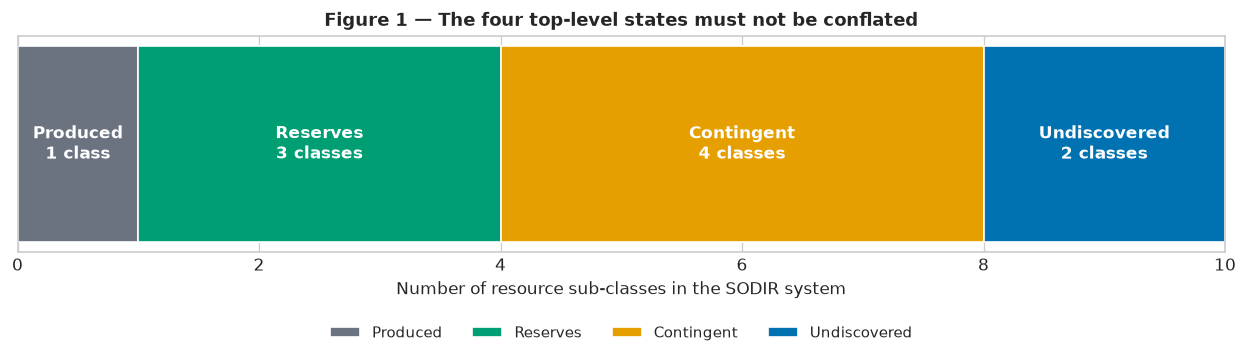

In [4]:
category_order = ["Produced", "Reserves", "Contingent", "Undiscovered"]
category_counts = (
    resource_classes.groupby("Main category")["RC"]
    .count()
    .reindex(category_order)
)
category_colors = [
    COLORS["produced"],
    COLORS["reserves"],
    COLORS["contingent"],
    COLORS["undiscovered"],
]

figure, axis = plt.subplots(figsize=(10.5, 3.3))
left = 0
for category, count, color in zip(
    category_order,
    category_counts,
    category_colors,
):
    axis.barh(
        [0],
        [count],
        left=left,
        color=color,
        edgecolor="white",
        height=0.58,
        label=category,
    )
    axis.text(
        left + count / 2,
        0,
        f"{category}\n{count} class{'es' if count > 1 else ''}",
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )
    left += count

axis.set_xlim(0, int(category_counts.sum()))
axis.set_yticks([])
axis.set_xlabel("Number of resource sub-classes in the SODIR system")
axis.set_title("Figure 1 — The four top-level states must not be conflated")
axis.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=4,
)
figure.tight_layout()
plt.show()

## Four separate dimensions

| Dimension | Question | Examples | Must not be substituted by |
|---|---|---|---|
| Resource class | What project decision/maturity state exists? | RC5, RC4, RC3 | NPV, probability, simulation result |
| Project category | Is this first development or additional recovery? | F, A | field/discovery status |
| Volume uncertainty | What recoverable range is supported? | L, B, H | resource class |
| Geological chance | Will a mapped prospect discover petroleum? | $P_d$ for RC8 | a downward resource-class adjustment |

For stochastic reporting, SODIR describes the base estimate as the expected value. A low estimate
may be expressed as P90 (90% probability of recovering at least that amount), while a high estimate
may be expressed as P10. In cumulative-distribution notation those correspond to the 10th and 90th
percentiles, respectively.

Project category F is used for first development of a deposit. Category A is used for an additional
project that improves recovery from petroleum already in place. F/A is used only with RC2, RC3,
RC4, RC5, and RC7.

In [5]:
@dataclass(frozen=True)
class ResourceProject:
    project_id: str
    reporting_object: str
    project_name: str
    resource_class: int
    project_category: str
    oil_base_msm3: float
    gas_base_bsm3: float
    evidence_owner: str
    next_decision: str


projects = [
    ResourceProject(
        "P00",
        "Teaching Field",
        "Historic sales",
        0,
        "",
        42.0,
        18.0,
        "Production accounting",
        "Reconcile produced volumes",
    ),
    ResourceProject(
        "P01",
        "Teaching Field",
        "Base production project",
        1,
        "",
        14.0,
        9.0,
        "Asset team",
        "Operate and update forecast",
    ),
    ResourceProject(
        "P02",
        "Teaching Field",
        "Subsea compression",
        2,
        "A",
        1.2,
        4.5,
        "Project team",
        "Start production",
    ),
    ResourceProject(
        "P03",
        "Satellite Beta",
        "Sanctioned tie-back",
        3,
        "F",
        2.4,
        5.8,
        "Licence",
        "Obtain PDO approval",
    ),
    ResourceProject(
        "P04",
        "Teaching Field",
        "Low-pressure recovery",
        4,
        "A",
        0.8,
        3.2,
        "Concept team",
        "BOG",
    ),
    ResourceProject(
        "P05",
        "Discovery Alpha",
        "First-development tie-back",
        5,
        "F",
        0.9,
        10.5,
        "Feasibility team",
        "BOK",
    ),
    ResourceProject(
        "P06",
        "Discovery Gamma",
        "Currently stranded volume",
        6,
        "",
        0.5,
        1.0,
        "Licence",
        "Monitor enabling change",
    ),
    ResourceProject(
        "P07",
        "Discovery Delta",
        "Immature first development",
        7,
        "F",
        1.0,
        2.4,
        "Discovery evaluation",
        "BOI or shelve",
    ),
    ResourceProject(
        "P08",
        "Prospect Epsilon",
        "Mapped prospect",
        8,
        "",
        2.5,
        0.8,
        "Exploration team",
        "Drill or drop",
    ),
    ResourceProject(
        "P09",
        "Teaching Play",
        "Unmapped play potential",
        9,
        "",
        8.0,
        12.0,
        "Basin team",
        "Map leads and prospects",
    ),
]

project_register = pd.DataFrame([asdict(project) for project in projects])
project_register = project_register.merge(
    resource_classes[["RC", "Main category"]],
    left_on="resource_class",
    right_on="RC",
    validate="many_to_one",
).drop(columns="RC")
project_register.style.hide(axis="index").format(
    {
        "oil_base_msm3": "{:.2f}",
        "gas_base_bsm3": "{:.2f}",
    }
)

project_id,reporting_object,project_name,resource_class,project_category,oil_base_msm3,gas_base_bsm3,evidence_owner,next_decision,Main category
P00,Teaching Field,Historic sales,0,,42.00,18.00,Production accounting,Reconcile produced volumes,Produced
P01,Teaching Field,Base production project,1,,14.00,9.00,Asset team,Operate and update forecast,Reserves
P02,Teaching Field,Subsea compression,2,A,1.20,4.50,Project team,Start production,Reserves
P03,Satellite Beta,Sanctioned tie-back,3,F,2.40,5.80,Licence,Obtain PDO approval,Reserves
P04,Teaching Field,Low-pressure recovery,4,A,0.80,3.20,Concept team,BOG,Contingent
P05,Discovery Alpha,First-development tie-back,5,F,0.90,10.50,Feasibility team,BOK,Contingent
P06,Discovery Gamma,Currently stranded volume,6,,0.50,1.00,Licence,Monitor enabling change,Contingent
P07,Discovery Delta,Immature first development,7,F,1.00,2.40,Discovery evaluation,BOI or shelve,Contingent
P08,Prospect Epsilon,Mapped prospect,8,,2.50,0.80,Exploration team,Drill or drop,Undiscovered
P09,Teaching Play,Unmapped play potential,9,,8.00,12.00,Basin team,Map leads and prospects,Undiscovered


In [6]:
f_or_a_classes = {2, 3, 4, 5, 7}
allowed_project_category = []
for row in project_register.itertuples(index=False):
    if row.resource_class in f_or_a_classes:
        allowed_project_category.append(row.project_category in {"F", "A"})
    else:
        allowed_project_category.append(row.project_category == "")

register_quality = pd.Series(
    {
        "All RC0–RC9 represented": set(project_register["resource_class"])
        == set(range(10)),
        "Project identifiers unique": project_register["project_id"].is_unique,
        "F/A rules respected": all(allowed_project_category),
        "Base volumes non-negative": bool(
            (
                project_register[["oil_base_msm3", "gas_base_bsm3"]]
                >= 0.0
            ).all().all()
        ),
        "Every project has an evidence owner": bool(
            project_register["evidence_owner"].str.len().gt(0).all()
        ),
    },
    name="register quality gate",
)
register_quality.to_frame()

,register quality gate
All RC0–RC9 represented,True
Project identifiers unique,True
F/A rules respected,True
Base volumes non-negative,True
Every project has an evidence owner,True


## Maturity is a graph of decisions, not a one-way numerical score

The most common development route is RC9 → RC8 → RC7 → RC5 → RC4 → RC3 → RC2 → RC1 → RC0.
Real projects can be postponed, re-scoped, or moved to RC6 when production is unlikely. Reactivation
can occur when technology, infrastructure access, price, or another enabling condition changes.

- **BOI** — decision to initiate feasibility work; normally RC7 → RC5.
- **BOK** — decision to concretise at least one feasible concept; normally RC5 → RC4.
- **BOV** — decision to continue one concept; important within RC4, but not a separate RC boundary.
- **BOG** — decision to implement; normally RC4 → RC3.
- **PDO approval or exemption** — normally RC3 → RC2.
- **Production start** — RC2 → RC1.
- **Produced and sold** — volumes accumulate in RC0 while remaining volumes stay in RC1.

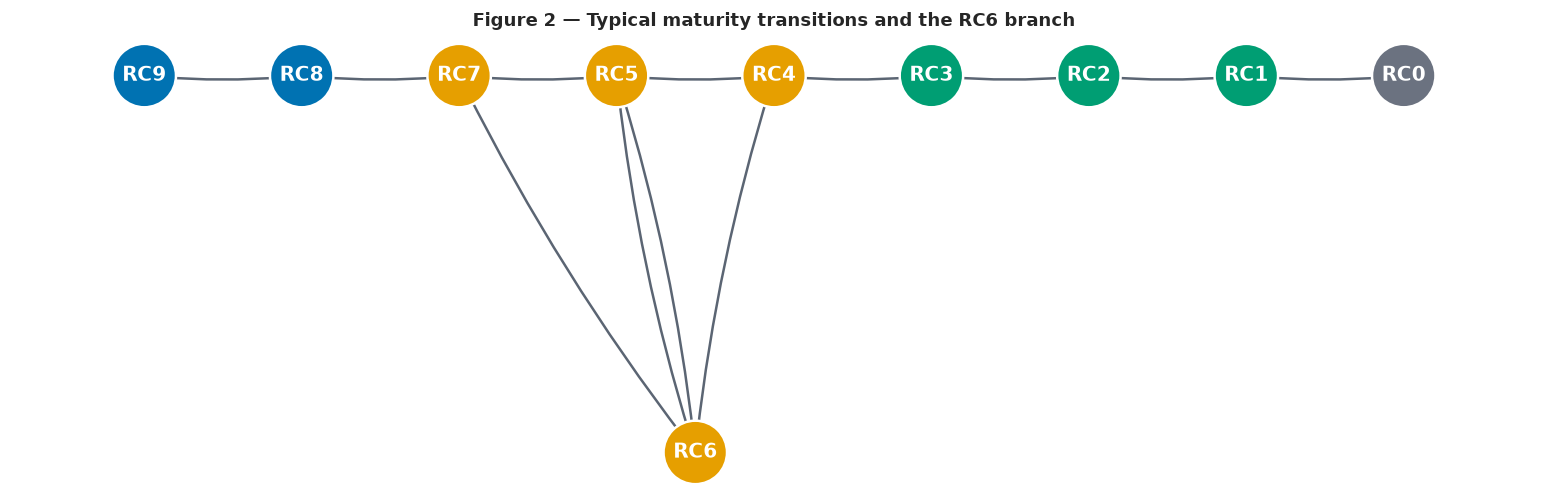

In [7]:
maturity_graph = nx.DiGraph()
maturity_edges = [
    ("RC9", "RC8", "Map prospect"),
    ("RC8", "RC7", "Discovery"),
    ("RC7", "RC5", "BOI"),
    ("RC5", "RC4", "BOK"),
    ("RC4", "RC3", "BOG"),
    ("RC3", "RC2", "PDO approval"),
    ("RC2", "RC1", "Production start"),
    ("RC1", "RC0", "Produced and sold"),
    ("RC7", "RC6", "Production unlikely"),
    ("RC5", "RC6", "Shelve"),
    ("RC4", "RC6", "Shelve"),
    ("RC6", "RC5", "Enabling change + BOI"),
]
for source, target, decision in maturity_edges:
    maturity_graph.add_edge(source, target, decision=decision)

positions = {
    "RC9": (0.0, 0.0),
    "RC8": (1.2, 0.0),
    "RC7": (2.4, 0.0),
    "RC5": (3.6, 0.0),
    "RC4": (4.8, 0.0),
    "RC3": (6.0, 0.0),
    "RC2": (7.2, 0.0),
    "RC1": (8.4, 0.0),
    "RC0": (9.6, 0.0),
    "RC6": (4.2, -1.3),
}
node_colors = []
for node in maturity_graph.nodes:
    rc_value = int(node.removeprefix("RC"))
    if rc_value == 0:
        node_colors.append(COLORS["produced"])
    elif rc_value in {1, 2, 3}:
        node_colors.append(COLORS["reserves"])
    elif rc_value in {4, 5, 6, 7}:
        node_colors.append(COLORS["contingent"])
    else:
        node_colors.append(COLORS["undiscovered"])

figure, axis = plt.subplots(figsize=(13.0, 4.3))
nx.draw_networkx_nodes(
    maturity_graph,
    positions,
    node_color=node_colors,
    node_size=1450,
    edgecolors="white",
    linewidths=1.5,
    ax=axis,
)
nx.draw_networkx_labels(
    maturity_graph,
    positions,
    font_color="white",
    font_weight="bold",
    ax=axis,
)
nx.draw_networkx_edges(
    maturity_graph,
    positions,
    arrows=True,
    arrowsize=16,
    width=1.5,
    edge_color="#5B6573",
    connectionstyle="arc3,rad=0.05",
    ax=axis,
)
axis.set_title("Figure 2 — Typical maturity transitions and the RC6 branch")
axis.set_axis_off()
figure.tight_layout()
plt.show()

In [8]:
decision_gates = pd.DataFrame(
    [
        ("Prospect mapped", "RC9 → RC8", "Mapped closure, reservoir and chance model"),
        ("Discovery", "RC8 → RC7", "Well evidence establishes mobile petroleum"),
        ("BOI", "RC7 → RC5", "Feasibility work starts"),
        ("BOK", "RC5 → RC4", "At least one technically and financially feasible concept"),
        ("BOV", "Within RC4", "One concept selected for continued definition"),
        ("BOG", "RC4 → RC3", "Licensees decide to implement"),
        ("PDO approval", "RC3 → RC2", "Authority approval or exemption"),
        ("First production", "RC2 → RC1", "Project starts producing"),
        ("Sale and delivery", "RC1 → RC0", "Produced volume becomes historic production"),
    ],
    columns=["Milestone", "Typical classification effect", "Minimum interpretation"],
)
decision_gates.style.hide(axis="index")

Milestone,Typical classification effect,Minimum interpretation
Prospect mapped,RC9 → RC8,"Mapped closure, reservoir and chance model"
Discovery,RC8 → RC7,Well evidence establishes mobile petroleum
BOI,RC7 → RC5,Feasibility work starts
BOK,RC5 → RC4,At least one technically and financially feasible concept
BOV,Within RC4,One concept selected for continued definition
BOG,RC4 → RC3,Licensees decide to implement
PDO approval,RC3 → RC2,Authority approval or exemption
First production,RC2 → RC1,Project starts producing
Sale and delivery,RC1 → RC0,Produced volume becomes historic production


# Part II — Public data and the wider notebook chain

SODIR publishes FactPages downloads and ArcGIS/FactMaps services under the Norwegian Licence for
Open Government Data (NLOD). Public field/discovery/resource attributes can seed a portfolio
register, but they do not replace operator RNB evidence, current licence decisions, confidential
models, host-capacity confirmation, or authority classification.

The loader contract below is deliberately **off by default** so this retained notebook remains a
reproducible snapshot. Set `LIVE_SODIR = True` in a fresh Colab session to test a current ArcGIS
layer after checking the live service metadata and field names.

In [9]:
SODIR_ARCGIS = (
    "https://factmaps.sodir.no/api/rest/services/"
    "Factmaps/FactMapsWGS84/FeatureServer"
)
LIVE_SODIR = False


def fetch_sodir_attributes(
    layer_id,
    out_fields,
    where="1=1",
    record_limit=100,
):
    response = requests.get(
        f"{SODIR_ARCGIS}/{layer_id}/query",
        params={
            "where": where,
            "outFields": ",".join(out_fields),
            "returnGeometry": "false",
            "resultRecordCount": record_limit,
            "f": "json",
        },
        timeout=60,
    )
    response.raise_for_status()
    payload = response.json()
    if "error" in payload:
        raise RuntimeError(payload["error"])
    return pd.DataFrame(
        feature["attributes"]
        for feature in payload.get("features", [])
    )


source_register = pd.DataFrame(
    [
        (
            "Classification and definitions",
            "SODIR guideline updated 2024",
            "Frozen official reference",
        ),
        (
            "Fields, discoveries and resources",
            "SODIR FactPages / FactMaps",
            "Optional live public metadata",
        ),
        (
            "Project decisions and RNB forecasts",
            "Responsible licence / RNB process",
            "Controlled evidence, not inferred here",
        ),
        (
            "Fluid, process and capacity",
            "NeqSim plus discipline models",
            "Synthetic executable teaching case",
        ),
        (
            "Economics and commercial terms",
            "Reviewed project assumptions",
            "Synthetic screen only",
        ),
    ],
    columns=["Information", "Authoritative owner/source", "Notebook treatment"],
)
display(source_register.style.hide(axis="index"))
print(f"Live SODIR retrieval enabled: {LIVE_SODIR}")

Live SODIR retrieval enabled: False


Information,Authoritative owner/source,Notebook treatment
Classification and definitions,SODIR guideline updated 2024,Frozen official reference
"Fields, discoveries and resources",SODIR FactPages / FactMaps,Optional live public metadata
Project decisions and RNB forecasts,Responsible licence / RNB process,"Controlled evidence, not inferred here"
"Fluid, process and capacity",NeqSim plus discipline models,Synthetic executable teaching case
Economics and commercial terms,Reviewed project assumptions,Synthetic screen only


## Continue through the companion notebooks

Use this notebook as the resource-register and decision-governance layer between the following
specialist workflows:

1. [NCS area opening, licensing, exploration and discovery](ncs_area_opening_licensing_exploration_to_discovery.ipynb)
   — RC9/RC8 chance, success-case volume, drilling, and the RC7 discovery handoff.
2. [SEG-Y to field-development decisions](segyio_to_field_development_workflow.ipynb)
   — seismic interpretation, low/base/high STOIIP, wells, facilities, and DG evidence.
3. [Subsurface data to OPM Flow forecast](../reservoir/subsurface_data_to_opm_flow_production_forecast.ipynb)
   — dynamic recoverability and rate profiles.
4. [Producer and injector count and placement](well_count_and_placement_workflow.ipynb)
   — development architecture, deliverability, injectivity, and facility coupling.
5. [Norwegian field and area development](norwegian_field_and_area_development_with_neqsim.ipynb)
   — lifecycle production, facilities, emissions, host holdback, and economics.
6. [Offshore facility concept selection](offshore_facility_concept_selection_with_neqsim.ipynb)
   — technical gates, metocean, tie-back hydraulics, concepts, uncertainty, and MCDA.
7. [NCS tie-in quality, tariffs, holdback and tax](ncs_tie_in_quality_tariff_tax.ipynb)
   — the marketability/reference-point boundary after the upstream resource estimate.
8. [NPV of a gas-field tie-back](npv.ipynb)
   — a deeper economic and tax screen.

The handoff should preserve `project_id`, `reporting_object`, resource class, F/A category,
uncertainty identity, fluid composition, rate profile, reference point, source date, model version,
and accountable owner. Never send only a single unlabelled “P50” number downstream.

# Part III — What NeqSim contributes to resource evidence

NeqSim does not assign RC labels. It can strengthen the evidence used at BOI/BOK/BOV/BOG and in
RNB reporting by calculating:

- reservoir-fluid and wellstream phase behaviour;
- separation and stabilisation product yields;
- gas compression power and process capacity;
- product state at a defined reference boundary;
- mass and energy consistency; and
- sensitivities to composition, pressure, temperature, rate, and process configuration.

This synthetic process uses SRK with classic mixing, explicit multiphase checking, a wellstream at
180 bara and 85 °C, inlet letdown to 70 bara, cooling to 32 °C, three-phase separation, gas
compression to 120 bara, and a simple 2 bara condensate stabilisation flash. It is a screening
model, not a complete sales-gas or oil-specification process.

In [10]:
wellstream_composition = {
    "nitrogen": 0.006,
    "CO2": 0.018,
    "methane": 0.795,
    "ethane": 0.080,
    "propane": 0.045,
    "i-butane": 0.014,
    "n-butane": 0.014,
    "n-pentane": 0.008,
    "n-hexane": 0.006,
    "n-heptane": 0.004,
    "water": 0.010,
}


def make_wellstream_fluid(flow_kg_per_h):
    fluid = SystemSrkEos(273.15 + 85.0, 180.0)
    for component_name, mole_fraction in wellstream_composition.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_kg_per_h, "kg/hr")
    return fluid


composition_table = pd.DataFrame(
    {
        "Component": list(wellstream_composition),
        "Mole fraction [-]": list(wellstream_composition.values()),
    }
)
composition_table.style.hide(axis="index").format(
    {"Mole fraction [-]": "{:.4f}"}
)

Component,Mole fraction [-]
nitrogen,0.0060
CO2,0.0180
methane,0.7950
ethane,0.0800
propane,0.0450
i-butane,0.0140
n-butane,0.0140
n-pentane,0.0080
n-hexane,0.0060
n-heptane,0.0040


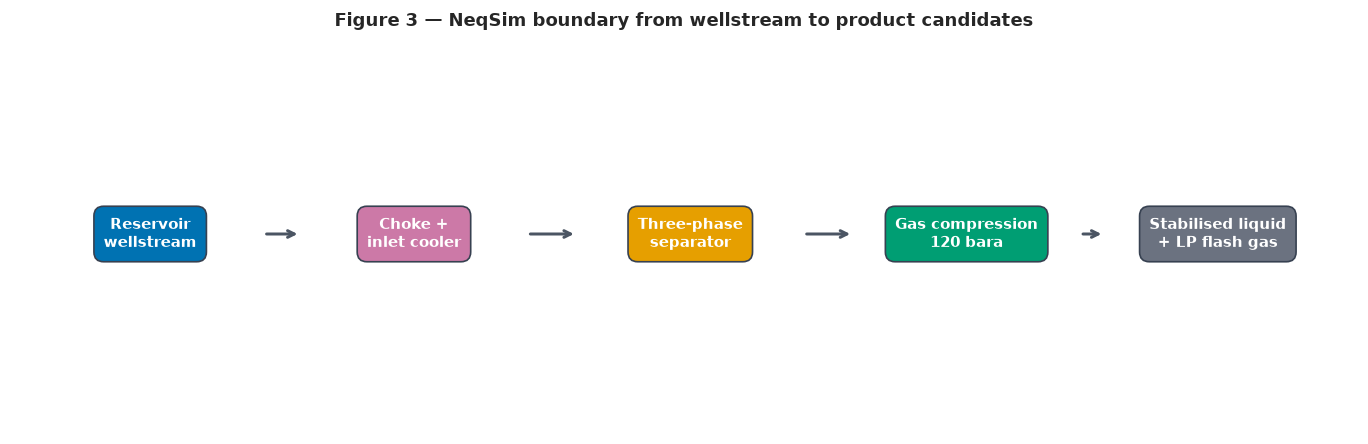

In [11]:
figure, axis = plt.subplots(figsize=(11.5, 3.8))
axis.set_axis_off()
process_nodes = [
    (0.07, "Reservoir\nwellstream", COLORS["undiscovered"]),
    (0.28, "Choke +\ninlet cooler", COLORS["purple"]),
    (0.50, "Three-phase\nseparator", COLORS["contingent"]),
    (0.72, "Gas compression\n120 bara", COLORS["reserves"]),
    (0.92, "Stabilised liquid\n+ LP flash gas", COLORS["produced"]),
]

for x_position, label, color in process_nodes:
    axis.text(
        x_position,
        0.50,
        label,
        ha="center",
        va="center",
        color="white",
        weight="bold",
        fontsize=9.0,
        bbox={
            "boxstyle": "round,pad=0.65",
            "facecolor": color,
            "edgecolor": "#374151",
        },
    )

for left_node, right_node in zip(process_nodes[:-1], process_nodes[1:]):
    axis.annotate(
        "",
        xy=(right_node[0] - 0.09, 0.50),
        xytext=(left_node[0] + 0.09, 0.50),
        arrowprops={
            "arrowstyle": "->",
            "color": "#4B5563",
            "linewidth": 1.8,
        },
    )

axis.set_xlim(-0.04, 1.03)
axis.set_ylim(0.20, 0.80)
axis.set_title(
    "Figure 3 — NeqSim boundary from wellstream to product candidates"
)
figure.tight_layout()
plt.show()

In [12]:
def build_process_case(feed_flow_kg_per_h=240_000.0):
    feed = Stream(
        "resource-case wellstream",
        make_wellstream_fluid(feed_flow_kg_per_h),
    )
    choke = ThrottlingValve("production choke", feed)
    choke.setOutletPressure(70.0, "bara")

    inlet_cooler = Cooler("inlet cooler", choke.getOutletStream())
    inlet_cooler.setOutTemperature(273.15 + 32.0)

    inlet_separator = ThreePhaseSeparator(
        "inlet separator",
        inlet_cooler.getOutletStream(),
    )

    export_compressor = Compressor(
        "export compressor",
        inlet_separator.getGasOutStream(),
    )
    export_compressor.setOutletPressure(120.0, "bara")
    export_compressor.setIsentropicEfficiency(0.78)

    export_aftercooler = Cooler(
        "export aftercooler",
        export_compressor.getOutletStream(),
    )
    export_aftercooler.setOutTemperature(273.15 + 35.0)

    liquid_letdown = ThrottlingValve(
        "liquid letdown",
        inlet_separator.getOilOutStream(),
    )
    liquid_letdown.setOutletPressure(2.0, "bara")

    stabilizer_heater = Heater(
        "stabilizer heater",
        liquid_letdown.getOutletStream(),
    )
    stabilizer_heater.setOutTemperature(273.15 + 40.0)

    stabilizer = ThreePhaseSeparator(
        "stabilizer flash",
        stabilizer_heater.getOutletStream(),
    )

    process = ProcessSystem()
    units = [
        feed,
        choke,
        inlet_cooler,
        inlet_separator,
        export_compressor,
        export_aftercooler,
        liquid_letdown,
        stabilizer_heater,
        stabilizer,
    ]
    for unit in units:
        process.add(unit)
    process.run()

    return {
        "process": process,
        "feed": feed,
        "inlet_separator": inlet_separator,
        "export_compressor": export_compressor,
        "export_aftercooler": export_aftercooler,
        "stabilizer": stabilizer,
    }


process_case = build_process_case()

In [13]:
feed_stream = process_case["feed"]
inlet_separator = process_case["inlet_separator"]
export_compressor = process_case["export_compressor"]
export_gas = process_case["export_aftercooler"].getOutletStream()
stabilizer = process_case["stabilizer"]

separator_gas = inlet_separator.getGasOutStream()
separator_oil = inlet_separator.getOilOutStream()
separator_water = inlet_separator.getWaterOutStream()
lp_flash_gas = stabilizer.getGasOutStream()
stabilized_oil = stabilizer.getOilOutStream()

feed_mass_kg_h = feed_stream.getFlowRate("kg/hr")
separator_mass_out_kg_h = sum(
    stream.getFlowRate("kg/hr")
    for stream in [separator_gas, separator_oil, separator_water]
)
stabilizer_mass_out_kg_h = sum(
    stream.getFlowRate("kg/hr")
    for stream in [lp_flash_gas, stabilized_oil]
)
separator_mass_residual = abs(
    feed_mass_kg_h - separator_mass_out_kg_h
) / feed_mass_kg_h
stabilizer_mass_residual = abs(
    separator_oil.getFlowRate("kg/hr") - stabilizer_mass_out_kg_h
) / separator_oil.getFlowRate("kg/hr")

process_summary = pd.DataFrame(
    [
        ("Feed", feed_mass_kg_h, 180.0, 85.0),
        (
            "HP gas",
            separator_gas.getFlowRate("kg/hr"),
            separator_gas.getPressure("bara"),
            separator_gas.getTemperature("C"),
        ),
        (
            "HP condensate",
            separator_oil.getFlowRate("kg/hr"),
            separator_oil.getPressure("bara"),
            separator_oil.getTemperature("C"),
        ),
        (
            "Produced water",
            separator_water.getFlowRate("kg/hr"),
            separator_water.getPressure("bara"),
            separator_water.getTemperature("C"),
        ),
        (
            "LP flash gas",
            lp_flash_gas.getFlowRate("kg/hr"),
            lp_flash_gas.getPressure("bara"),
            lp_flash_gas.getTemperature("C"),
        ),
        (
            "Stabilised liquid",
            stabilized_oil.getFlowRate("kg/hr"),
            stabilized_oil.getPressure("bara"),
            stabilized_oil.getTemperature("C"),
        ),
    ],
    columns=["Stream", "Mass flow [kg/h]", "Pressure [bara]", "Temperature [°C]"],
)
process_summary.style.hide(axis="index").format(
    {
        "Mass flow [kg/h]": "{:,.1f}",
        "Pressure [bara]": "{:.2f}",
        "Temperature [°C]": "{:.2f}",
    }
)

Stream,Mass flow [kg/h],Pressure [bara],Temperature [°C]
Feed,"240,000.0",180.00,85.00
HP gas,"226,716.2",70.00,32.00
HP condensate,"11,409.5",70.00,32.00
Produced water,"1,874.3",70.00,32.00
LP flash gas,"6,986.9",2.00,40.00
Stabilised liquid,"4,422.7",2.00,40.00


In [14]:
def standard_phase_volume_m3_day(stream, requested_phase):
    standard_system = stream.getThermoSystem().clone()
    standard_system.setTemperature(15.0, "C")
    standard_system.setPressure(1.01325, "bara")
    ThermodynamicOperations(standard_system).TPflash()
    standard_system.initPhysicalProperties()

    for phase_index in range(standard_system.getNumberOfPhases()):
        phase = standard_system.getPhase(phase_index)
        phase_name = str(phase.getPhaseTypeName()).lower()
        if phase_name == requested_phase.lower():
            return 24.0 * phase.getFlowRate("m3/hr")
    return 0.0


hp_gas_sm3_day = standard_phase_volume_m3_day(export_gas, "gas")
lp_gas_sm3_day = standard_phase_volume_m3_day(lp_flash_gas, "gas")
oil_sm3_day = standard_phase_volume_m3_day(stabilized_oil, "oil")

gas_recovery_fraction = 0.95
gas_marketability_fraction = 0.98
oil_marketability_fraction = 0.995

sales_gas_sm3_day = (
    hp_gas_sm3_day + gas_recovery_fraction * lp_gas_sm3_day
) * gas_marketability_fraction
sales_oil_sm3_day = oil_sm3_day * oil_marketability_fraction

hydrocarbon_mass_kg_h = (
    separator_gas.getFlowRate("kg/hr")
    + separator_oil.getFlowRate("kg/hr")
)
gas_yield_bsm3_per_mt = sales_gas_sm3_day / (
    hydrocarbon_mass_kg_h * 24.0
)
oil_yield_msm3_per_mt = 1000.0 * sales_oil_sm3_day / (
    hydrocarbon_mass_kg_h * 24.0
)

product_boundary = pd.Series(
    {
        "Conditioned gas candidate [MSm3/d]": hp_gas_sm3_day / 1.0e6,
        "LP flash gas [MSm3/d]": lp_gas_sm3_day / 1.0e6,
        "Screened marketable gas [MSm3/d]": sales_gas_sm3_day / 1.0e6,
        "Screened marketable condensate [Sm3/d]": sales_oil_sm3_day,
        "Gas yield [BSm3/Mt recovered HC]": gas_yield_bsm3_per_mt,
        "Condensate yield [MSm3/Mt recovered HC]": oil_yield_msm3_per_mt,
        "Export compressor power [MW]": export_compressor.getPower("kW")
        / 1000.0,
        "Separator relative mass residual": separator_mass_residual,
        "Stabilizer relative mass residual": stabilizer_mass_residual,
    },
    name="NeqSim product-boundary screen",
)
product_boundary.to_frame().style.format("{:.6g}")

,NeqSim product-boundary screen
Conditioned gas candidate [MSm3/d],6.15589
LP flash gas [MSm3/d],0.0913401
Screened marketable gas [MSm3/d],6.11781
Screened marketable condensate [Sm3/d],156.529
Gas yield [BSm3/Mt recovered HC],1.07048
Condensate yield [MSm3/Mt recovered HC],0.0273891
Export compressor power [MW],4.7053
Separator relative mass residual,8.48862e-15
Stabilizer relative mass residual,5.73939e-15


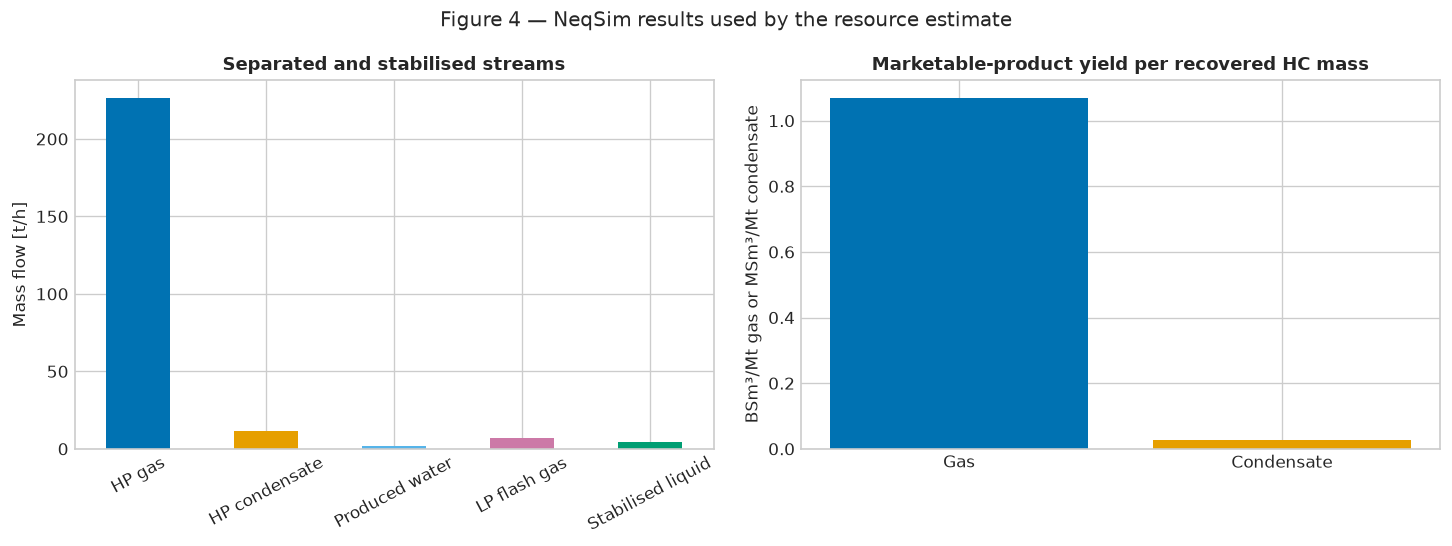

In [15]:
plot_values = pd.Series(
    {
        "HP gas": separator_gas.getFlowRate("kg/hr") / 1000.0,
        "HP condensate": separator_oil.getFlowRate("kg/hr") / 1000.0,
        "Produced water": separator_water.getFlowRate("kg/hr") / 1000.0,
        "LP flash gas": lp_flash_gas.getFlowRate("kg/hr") / 1000.0,
        "Stabilised liquid": stabilized_oil.getFlowRate("kg/hr") / 1000.0,
    }
)

figure, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))
plot_values.plot(
    kind="bar",
    color=[
        COLORS["undiscovered"],
        COLORS["contingent"],
        "#56B4E9",
        COLORS["purple"],
        COLORS["reserves"],
    ],
    ax=axes[0],
)
axes[0].set_ylabel("Mass flow [t/h]")
axes[0].set_title("Separated and stabilised streams")
axes[0].tick_params(axis="x", rotation=28)

axes[1].bar(
    ["Gas", "Condensate"],
    [gas_yield_bsm3_per_mt, oil_yield_msm3_per_mt],
    color=[COLORS["undiscovered"], COLORS["contingent"]],
)
axes[1].set_ylabel("BSm³/Mt gas or MSm³/Mt condensate")
axes[1].set_title("Marketable-product yield per recovered HC mass")
figure.suptitle("Figure 4 — NeqSim results used by the resource estimate")
figure.tight_layout()
plt.show()

# Part IV — Derive L/B/H recoverable sales products

For an educational discovered project, let $M_{HCIP}$ be hydrocarbon mass initially in place,
$RF$ the recovery factor, and $A_m$ an explicit marketability/availability factor. The process
model supplies product yields $Y_g$ and $Y_o$ at the defined boundary:

$$M_{rec}=M_{HCIP}RF$$

$$V_g=M_{rec}A_mY_g,\qquad V_o=M_{rec}A_mY_o$$

`SciPy` Latin-hypercube sampling is used to cover the input distributions efficiently. The
reported low estimate is the 10th cumulative percentile (P90 exceedance), the base is the expected
value, and the high estimate is the 90th cumulative percentile (P10 exceedance). This is a
synthetic uncertainty model; a real project must use its governed static/dynamic reservoir,
well, uptime, process, metering, and commercial models.

In [16]:
realizations = 40_000
sampler = qmc.LatinHypercube(d=4, seed=SEED)
uniform_samples = sampler.random(realizations)

hcip_mean_mt = 18.0
hcip_log_sigma = 0.28
hcip_log_scale = hcip_mean_mt / math.exp(
    0.5 * hcip_log_sigma**2
)
hcip_mass_mt = stats.lognorm.ppf(
    uniform_samples[:, 0],
    s=hcip_log_sigma,
    scale=hcip_log_scale,
)

recovery_fraction = 0.35 + 0.37 * stats.beta.ppf(
    uniform_samples[:, 1],
    a=5.0,
    b=4.0,
)
marketability = 0.92 + 0.075 * stats.beta.ppf(
    uniform_samples[:, 2],
    a=8.0,
    b=2.0,
)
fluid_yield_factor = stats.lognorm.ppf(
    uniform_samples[:, 3],
    s=0.035,
    scale=math.exp(-0.5 * 0.035**2),
)

recoverable_hydrocarbon_mt = hcip_mass_mt * recovery_fraction
gas_resources_bsm3 = (
    recoverable_hydrocarbon_mt
    * marketability
    * gas_yield_bsm3_per_mt
    * fluid_yield_factor
)
oil_resources_msm3 = (
    recoverable_hydrocarbon_mt
    * marketability
    * oil_yield_msm3_per_mt
    / fluid_yield_factor
)

resource_samples = pd.DataFrame(
    {
        "HCIP mass [Mt]": hcip_mass_mt,
        "Recovery fraction [-]": recovery_fraction,
        "Marketability factor [-]": marketability,
        "Gas [BSm3]": gas_resources_bsm3,
        "Condensate [MSm3]": oil_resources_msm3,
    }
)
resource_samples.describe(percentiles=[0.10, 0.50, 0.90]).T

,count,mean,std,min,10%,50%,90%,max
HCIP mass [Mt],40000.0,17.999881,5.139650,5.072588,12.089666,17.308010,24.779001,54.632070
Recovery fraction [-],40000.0,0.555556,0.058141,0.367636,0.477517,0.557143,0.631320,0.710777
Marketability factor [-],40000.0,0.980000,0.009046,0.932745,0.967373,0.981529,0.990442,0.994989
Gas [BSm3],40000.0,10.489835,3.229944,3.067705,6.791123,10.037448,14.737721,36.591302
Condensate [MSm3],40000.0,0.268705,0.082625,0.076488,0.174085,0.257495,0.377590,0.906387


In [17]:
def low_base_high(values):
    return {
        "P90 low": float(np.quantile(values, 0.10)),
        "Base expected": float(np.mean(values)),
        "P10 high": float(np.quantile(values, 0.90)),
    }


resource_estimates = pd.DataFrame(
    {
        "Gas [BSm3]": low_base_high(gas_resources_bsm3),
        "Condensate [MSm3]": low_base_high(oil_resources_msm3),
    }
).T
resource_estimates

,P90 low,Base expected,P10 high
Gas [BSm3],6.791123,10.489835,14.737721
Condensate [MSm3],0.174085,0.268705,0.377590


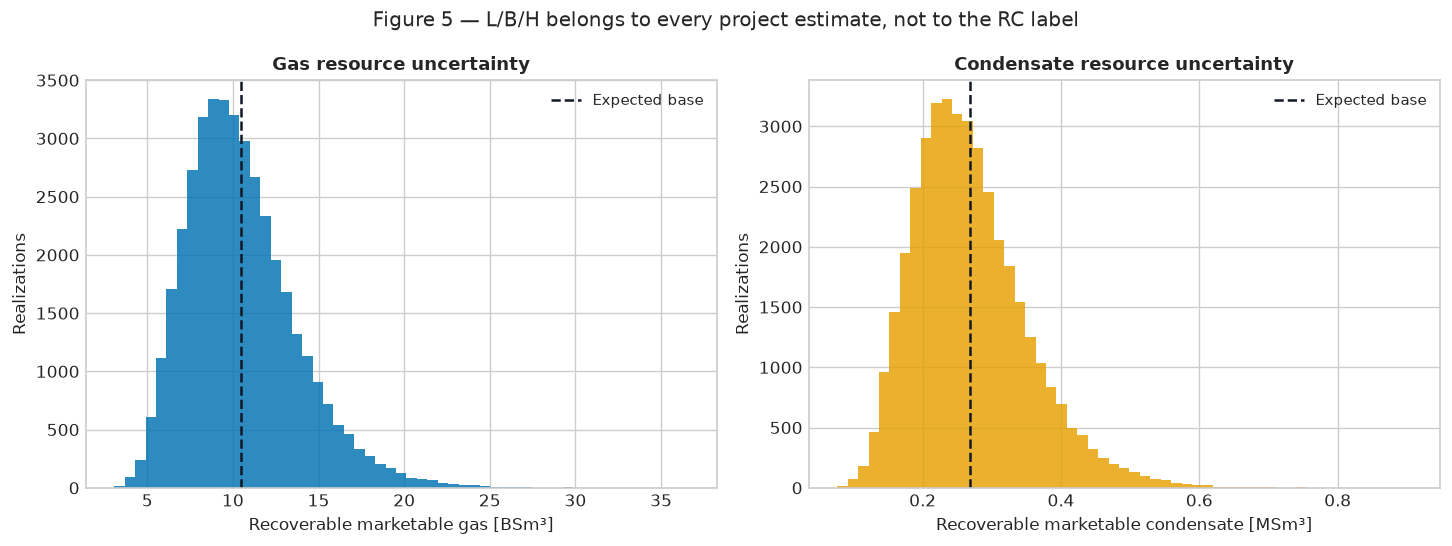

In [18]:
figure, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))
axes[0].hist(
    gas_resources_bsm3,
    bins=55,
    color=COLORS["undiscovered"],
    alpha=0.82,
)
axes[0].axvline(
    resource_estimates.loc["Gas [BSm3]", "Base expected"],
    color="#111827",
    linestyle="--",
    label="Expected base",
)
axes[0].set_xlabel("Recoverable marketable gas [BSm³]")
axes[0].set_ylabel("Realizations")
axes[0].set_title("Gas resource uncertainty")
axes[0].legend()

axes[1].hist(
    oil_resources_msm3,
    bins=55,
    color=COLORS["contingent"],
    alpha=0.82,
)
axes[1].axvline(
    resource_estimates.loc["Condensate [MSm3]", "Base expected"],
    color="#111827",
    linestyle="--",
    label="Expected base",
)
axes[1].set_xlabel("Recoverable marketable condensate [MSm³]")
axes[1].set_ylabel("Realizations")
axes[1].set_title("Condensate resource uncertainty")
axes[1].legend()
figure.suptitle("Figure 5 — L/B/H belongs to every project estimate, not to the RC label")
figure.tight_layout()
plt.show()

## Geological chance is separate from resource class

For a mapped RC8 prospect, the success-case distribution is conditional on discovery. A
risk-weighted aggregation may use:

$$E[V_{undiscovered}]=P_dE[V\mid\mathrm{discovery}]$$

That multiplication does **not** turn RC8 into RC6 or RC7. On a discovery, the project is
re-estimated from well evidence and normally enters RC7 while evaluation is incomplete. For the
discovered RC5 teaching project used above, $P_d=1$ because discovery risk is no longer relevant;
development, performance, commercial, and schedule uncertainties remain.

In [19]:
prospect_discovery_probability = 0.28
success_case_gas_bsm3 = resource_estimates.loc[
    "Gas [BSm3]",
    "Base expected",
]
risk_weighted_gas_bsm3 = (
    prospect_discovery_probability * success_case_gas_bsm3
)

chance_separation = pd.DataFrame(
    [
        (
            "RC8 mapped prospect",
            8,
            prospect_discovery_probability,
            success_case_gas_bsm3,
            risk_weighted_gas_bsm3,
        ),
        (
            "RC5 discovered project",
            5,
            1.0,
            success_case_gas_bsm3,
            success_case_gas_bsm3,
        ),
    ],
    columns=[
        "Case",
        "Resource class",
        "Discovery probability",
        "Success/discovered gas [BSm3]",
        "Risk-weighted gas [BSm3]",
    ],
)
chance_separation.style.hide(axis="index").format(
    {
        "Discovery probability": "{:.2f}",
        "Success/discovered gas [BSm3]": "{:.3f}",
        "Risk-weighted gas [BSm3]": "{:.3f}",
    }
)

Case,Resource class,Discovery probability,Success/discovered gas [BSm3],Risk-weighted gas [BSm3]
RC8 mapped prospect,8,0.28,10.490,2.937
RC5 discovered project,5,1.00,10.490,10.490


# Part V — Convert classified volumes to rate and capacity evidence

Resource classification concerns volumes attached to projects, while development decisions require
time profiles. A simple capacity-limited plateau-and-decline function demonstrates the handoff.
The NeqSim screened gas rate is treated as the facility boundary; a design margin is retained.
The numerical profile is intentionally transparent so it can be replaced by OPM Flow, ERT/FMU,
well-network, availability, and host-allocation outputs from the companion notebooks.

In [20]:
facility_design_fraction = 0.85
gas_capacity_bsm3_year = (
    sales_gas_sm3_day
    * facility_design_fraction
    * 365.0
    / 1.0e9
)


def build_capacity_limited_profile(
    total_gas_bsm3,
    total_oil_msm3,
    scenario,
    start_year=2031,
    plateau_years=4,
    annual_decline=0.13,
):
    remaining_gas = float(total_gas_bsm3)
    rows = []
    year_index = 0
    while remaining_gas > 1.0e-8 and year_index < 50:
        if year_index < plateau_years:
            target_gas = gas_capacity_bsm3_year
        else:
            target_gas = gas_capacity_bsm3_year * math.exp(
                -annual_decline * (year_index - plateau_years + 1)
            )
        gas_volume = min(remaining_gas, target_gas)
        oil_volume = total_oil_msm3 * gas_volume / total_gas_bsm3
        rows.append(
            {
                "Scenario": scenario,
                "Year": start_year + year_index,
                "Gas [BSm3/y]": gas_volume,
                "Condensate [MSm3/y]": oil_volume,
                "Capacity utilization [-]": gas_volume
                / gas_capacity_bsm3_year,
            }
        )
        remaining_gas -= gas_volume
        year_index += 1
    return pd.DataFrame(rows)


scenario_columns = {
    "LOW / P90": "P90 low",
    "BASE / expected": "Base expected",
    "HIGH / P10": "P10 high",
}
profile_frames = []
for scenario_name, estimate_column in scenario_columns.items():
    profile_frames.append(
        build_capacity_limited_profile(
            resource_estimates.loc["Gas [BSm3]", estimate_column],
            resource_estimates.loc["Condensate [MSm3]", estimate_column],
            scenario_name,
        )
    )
production_profiles = pd.concat(profile_frames, ignore_index=True)

profile_summary = production_profiles.groupby("Scenario").agg(
    start_year=("Year", "min"),
    end_year=("Year", "max"),
    gas_recovered_bsm3=("Gas [BSm3/y]", "sum"),
    condensate_recovered_msm3=("Condensate [MSm3/y]", "sum"),
    maximum_utilization=("Capacity utilization [-]", "max"),
)
profile_summary

,start_year,end_year,gas_recovered_bsm3,condensate_recovered_msm3,maximum_utilization
Scenario,,,,,
BASE / expected,2031,2036,10.489835,0.268705,1.0
HIGH / P10,2031,2040,14.737721,0.377590,1.0
LOW / P90,2031,2034,6.791123,0.174085,1.0


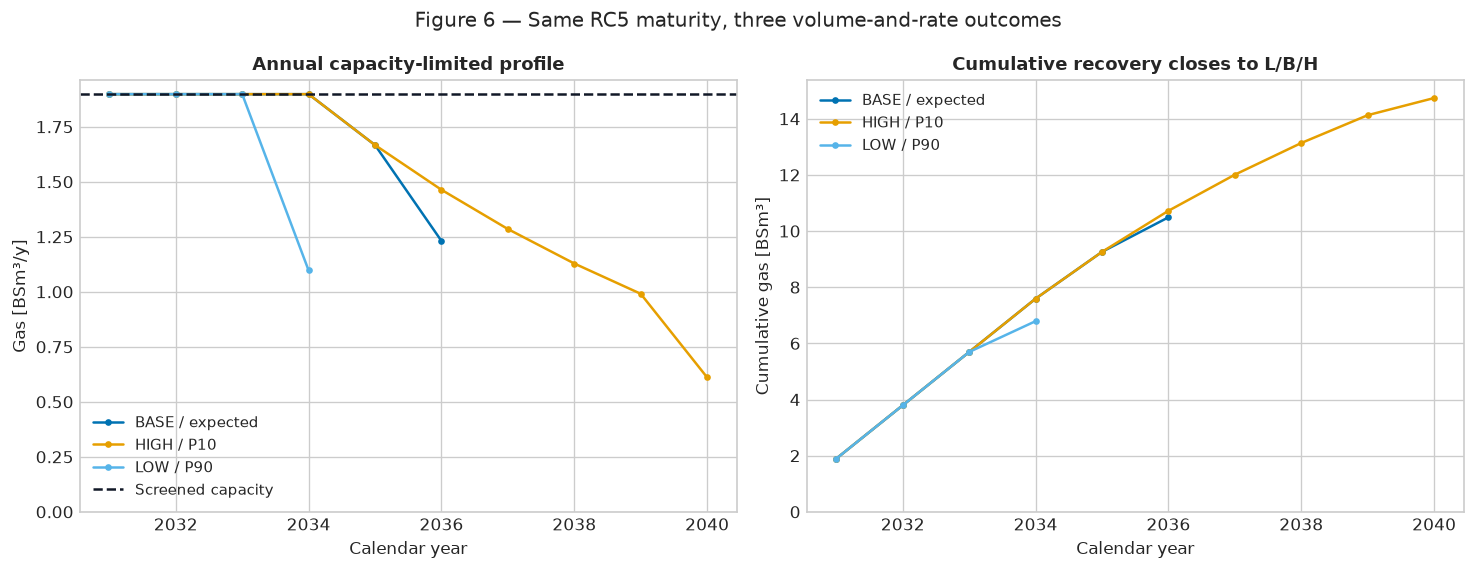

In [21]:
scenario_colors = {
    "LOW / P90": "#56B4E9",
    "BASE / expected": COLORS["undiscovered"],
    "HIGH / P10": COLORS["contingent"],
}

figure, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))
for scenario_name, frame in production_profiles.groupby("Scenario"):
    frame = frame.sort_values("Year")
    axes[0].plot(
        frame["Year"],
        frame["Gas [BSm3/y]"],
        marker="o",
        markersize=3,
        label=scenario_name,
        color=scenario_colors[scenario_name],
    )
    axes[1].plot(
        frame["Year"],
        frame["Gas [BSm3/y]"].cumsum(),
        marker="o",
        markersize=3,
        label=scenario_name,
        color=scenario_colors[scenario_name],
    )

axes[0].axhline(
    gas_capacity_bsm3_year,
    color="#111827",
    linestyle="--",
    label="Screened capacity",
)
axes[0].set_xlabel("Calendar year")
axes[0].set_ylabel("Gas [BSm³/y]")
axes[0].set_ylim(bottom=0.0)
axes[0].set_title("Annual capacity-limited profile")
axes[0].legend()
axes[1].set_xlabel("Calendar year")
axes[1].set_ylabel("Cumulative gas [BSm³]")
axes[1].set_ylim(bottom=0.0)
axes[1].set_title("Cumulative recovery closes to L/B/H")
axes[1].legend()
figure.suptitle("Figure 6 — Same RC5 maturity, three volume-and-rate outcomes")
figure.tight_layout()
plt.show()

# Part VI — Economics informs decisions but does not assign the class

Economics is part of the evidence for BOI/BOK/BOG and can make production likely or unlikely, but
the RC label records the resulting project maturity/decision state. The simplified pre-tax screen is:

$$NPV(r)=\sum_{t=0}^{T}\frac{CF_t}{(1+r)^t}$$

The synthetic case uses an 8% real discount rate, 2.5 NOK/Sm³ gas, 4,000 NOK/Sm³ condensate,
0.35 NOK/Sm³ variable gas transport, 0.55 billion NOK/year producing OPEX, and 13 billion NOK
pre-production CAPEX. It excludes tax, financing, tariff detail, host processing, abandonment,
reliability, emissions cost, and commercial allocation. Use the dedicated NPV and NCS tie-in
notebooks for deeper work.

In [22]:
gas_price_nok_sm3 = 2.50
condensate_price_nok_sm3 = 4_000.0
gas_transport_nok_sm3 = 0.35
annual_opex_bnok = 0.55
discount_rate = 0.08
capex_by_year_bnok = {
    2028: 6.5,
    2029: 4.5,
    2030: 2.0,
}


def discounted_cash_flow(profile):
    first_year = min(capex_by_year_bnok)
    last_year = int(profile["Year"].max())
    rows = []
    profile_by_year = profile.set_index("Year")
    for year in range(first_year, last_year + 1):
        if year in profile_by_year.index:
            gas_bsm3 = float(
                profile_by_year.loc[year, "Gas [BSm3/y]"]
            )
            oil_msm3 = float(
                profile_by_year.loc[year, "Condensate [MSm3/y]"]
            )
        else:
            gas_bsm3 = 0.0
            oil_msm3 = 0.0
        gas_revenue_bnok = gas_bsm3 * gas_price_nok_sm3
        oil_revenue_bnok = oil_msm3 * condensate_price_nok_sm3 / 1000.0
        transport_bnok = gas_bsm3 * gas_transport_nok_sm3
        opex_bnok = annual_opex_bnok if gas_bsm3 > 0.0 else 0.0
        capex_bnok = capex_by_year_bnok.get(year, 0.0)
        cash_flow_bnok = (
            gas_revenue_bnok
            + oil_revenue_bnok
            - transport_bnok
            - opex_bnok
            - capex_bnok
        )
        discount_factor = (1.0 + discount_rate) ** (year - first_year)
        rows.append(
            {
                "Year": year,
                "Cash flow [billion NOK]": cash_flow_bnok,
                "Discounted cash flow [billion NOK]": cash_flow_bnok
                / discount_factor,
            }
        )
    return pd.DataFrame(rows)


cash_flow_frames = []
npv_rows = []
for scenario_name, frame in production_profiles.groupby("Scenario"):
    scenario_cash_flow = discounted_cash_flow(frame)
    scenario_cash_flow["Scenario"] = scenario_name
    cash_flow_frames.append(scenario_cash_flow)
    npv_rows.append(
        {
            "Scenario": scenario_name,
            "Pre-tax NPV8 [billion NOK]": scenario_cash_flow[
                "Discounted cash flow [billion NOK]"
            ].sum(),
        }
    )

cash_flows = pd.concat(cash_flow_frames, ignore_index=True)
npv_table = pd.DataFrame(npv_rows).set_index("Scenario")
npv_table

,Pre-tax NPV8 [billion NOK]
Scenario,
BASE / expected,1.267462
HIGH / P10,4.695492
LOW / P90,-2.939677


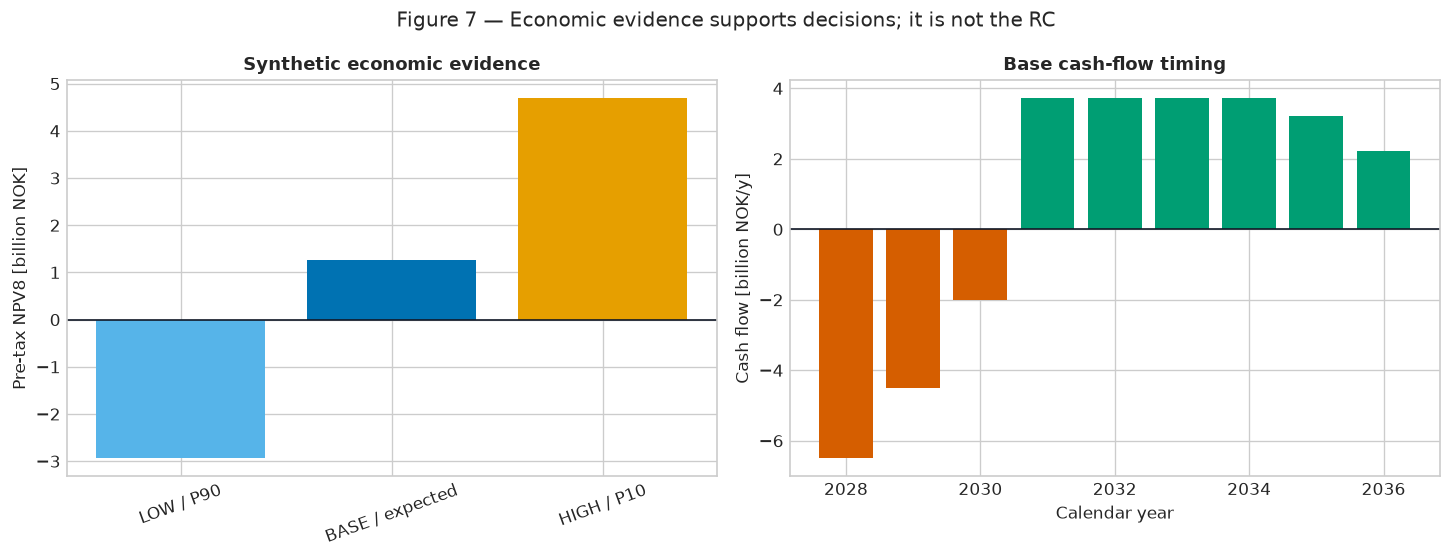

In [23]:
npv_plot = npv_table.reindex(scenario_columns).copy()
figure, axes = plt.subplots(1, 2, figsize=(12.2, 4.7))
axes[0].bar(
    npv_plot.index,
    npv_plot["Pre-tax NPV8 [billion NOK]"],
    color=[scenario_colors[name] for name in npv_plot.index],
)
axes[0].axhline(0.0, color="#111827", linewidth=1.0)
axes[0].set_ylabel("Pre-tax NPV8 [billion NOK]")
axes[0].set_title("Synthetic economic evidence")
axes[0].tick_params(axis="x", rotation=20)

base_cash_flow = cash_flows[
    cash_flows["Scenario"] == "BASE / expected"
]
axes[1].bar(
    base_cash_flow["Year"],
    base_cash_flow["Cash flow [billion NOK]"],
    color=np.where(
        base_cash_flow["Cash flow [billion NOK]"] >= 0.0,
        COLORS["reserves"],
        COLORS["unlikely"],
    ),
)
axes[1].axhline(0.0, color="#111827", linewidth=1.0)
axes[1].set_xlabel("Calendar year")
axes[1].set_ylabel("Cash flow [billion NOK/y]")
axes[1].set_title("Base cash-flow timing")
figure.suptitle("Figure 7 — Economic evidence supports decisions; it is not the RC")
figure.tight_layout()
plt.show()

# Part VII — Reusable handoff contract

An integrated agent or discipline workflow should exchange a contract rather than scrape figures
from a report. At minimum, preserve:

- reporting object, deposit/accumulation, and stable `project_id`;
- RC code and F/A category with decision dates and evidence owner;
- oil, NGL, condensate, and gas as separate sales products at the stated reference point;
- L/B/H identity, stochastic definition, and realization provenance;
- production profile, facility constraint, and curtailment/holdback basis;
- NeqSim model, composition, mixing rule, source commit, runtime JAR hash, and units;
- source document, data date, licence, confidentiality, and quality status; and
- open assumptions, limitations, and the next decision.

The cell writes a CSV and JSON package to a temporary directory and shows the key contents inline.
The files are useful for another notebook or agent, but the displayed tables remain the primary
evidence in this saved notebook.

In [24]:
alpha_project = project_register.loc[
    project_register["project_id"] == "P05"
].iloc[0]

resource_handoff = {
    "schema_version": "1.0",
    "project": {
        "project_id": alpha_project["project_id"],
        "reporting_object": alpha_project["reporting_object"],
        "project_name": alpha_project["project_name"],
        "resource_class": int(alpha_project["resource_class"]),
        "project_category": alpha_project["project_category"],
        "formal_classification_owner": alpha_project["evidence_owner"],
        "next_decision": alpha_project["next_decision"],
    },
    "resource_estimates": {
        product: {
            estimate: float(value)
            for estimate, value in row.items()
        }
        for product, row in resource_estimates.to_dict(orient="index").items()
    },
    "process_basis": {
        "thermodynamic_model": "SRK",
        "mixing_rule": "classic",
        "multiphase_check": True,
        "feed_flow_kg_h": float(feed_mass_kg_h),
        "separator_pressure_bara": 70.0,
        "separator_temperature_c": 32.0,
        "export_pressure_bara": 120.0,
        "neqsim_source_commit": NEQSIM_SOURCE_COMMIT,
        "neqsim_runtime_jar": NEQSIM_JAR.name,
        "neqsim_jar_sha256": NEQSIM_JAR_SHA256,
    },
    "uncertainty": {
        "method": "SciPy Latin hypercube with governed synthetic distributions",
        "realizations": realizations,
        "random_seed": SEED,
        "low_definition": "10th cumulative percentile / P90 exceedance",
        "base_definition": "expected value",
        "high_definition": "90th cumulative percentile / P10 exceedance",
    },
    "data_policy": {
        "official_guidance_date": "2024 update",
        "notebook_access_date": "2026-08-22",
        "live_sodir_data_used": LIVE_SODIR,
        "case_data": "synthetic teaching inputs",
    },
}

export_directory = Path(tempfile.gettempdir()) / (
    "neqsim_ncs_resource_classification_handoff"
)
export_directory.mkdir(parents=True, exist_ok=True)
register_path = export_directory / "resource_project_register.csv"
handoff_path = export_directory / "resource_handoff.json"
project_register.to_csv(register_path, index=False)
handoff_path.write_text(
    json.dumps(resource_handoff, indent=2),
    encoding="utf-8",
)

export_manifest = pd.DataFrame(
    [
        {
            "Artifact": register_path.name,
            "Bytes": register_path.stat().st_size,
            "SHA-256": hashlib.sha256(register_path.read_bytes()).hexdigest(),
        },
        {
            "Artifact": handoff_path.name,
            "Bytes": handoff_path.stat().st_size,
            "SHA-256": hashlib.sha256(handoff_path.read_bytes()).hexdigest(),
        },
    ]
)
display(export_manifest.style.hide(axis="index"))
print(json.dumps(resource_handoff["project"], indent=2))

{
  "project_id": "P05",
  "reporting_object": "Discovery Alpha",
  "project_name": "First-development tie-back",
  "resource_class": 5,
  "project_category": "F",
  "formal_classification_owner": "Feasibility team",
  "next_decision": "BOK"
}


Artifact,Bytes,SHA-256
resource_project_register.csv,1101,c47fc8d4585a614b68f092eb2ce6d7b060834cb52e4cdd750bae514d49af7353
resource_handoff.json,1638,247e6f80b8f698e2d61c49159514b1344d43f67d8bca19c057bf2be789dd183b


# Part VIII — End-to-end validation

The checks verify classification structure, project-category rules, graph reachability, NeqSim
composition and balances, positive process results, L/B/H ordering, separation of chance and
maturity, volume-to-profile closure, finite economics, and artifact integrity. These checks cannot
validate the synthetic assumptions as a real project basis.

In [25]:
profile_targets = {
    "LOW / P90": resource_estimates.loc["Gas [BSm3]", "P90 low"],
    "BASE / expected": resource_estimates.loc[
        "Gas [BSm3]",
        "Base expected",
    ],
    "HIGH / P10": resource_estimates.loc["Gas [BSm3]", "P10 high"],
}
profile_closure = all(
    math.isclose(
        profile_summary.loc[scenario, "gas_recovered_bsm3"],
        target,
        rel_tol=1.0e-10,
        abs_tol=1.0e-10,
    )
    for scenario, target in profile_targets.items()
)

engineering_checks = {
    "exact NeqSim source commit recorded": len(NEQSIM_SOURCE_COMMIT) == 40,
    "runtime class loaded from declared JAR": NEQSIM_JAR.name in class_source,
    "wellstream composition sums to one": math.isclose(
        sum(wellstream_composition.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "all RC0-RC9 are represented": set(resource_classes["RC"])
    == set(range(10)),
    "project register F/A rules pass": all(allowed_project_category),
    "typical path connects RC9 to RC0": nx.has_path(
        maturity_graph,
        "RC9",
        "RC0",
    ),
    "RC6 reactivation path exists": nx.has_path(
        maturity_graph,
        "RC6",
        "RC5",
    ),
    "separator mass balance closes": separator_mass_residual < 1.0e-8,
    "stabilizer mass balance closes": stabilizer_mass_residual < 1.0e-8,
    "compressor power is positive": export_compressor.getPower("kW") > 0.0,
    "screened marketable gas is positive": sales_gas_sm3_day > 0.0,
    "screened marketable condensate is positive": sales_oil_sm3_day > 0.0,
    "gas L-B-H estimates are ordered": bool(
        np.all(np.diff(resource_estimates.loc["Gas [BSm3]"]) > 0.0)
    ),
    "condensate L-B-H estimates are ordered": bool(
        np.all(
            np.diff(resource_estimates.loc["Condensate [MSm3]"]) > 0.0
        )
    ),
    "RC8 risk weighting is separate and lower": (
        risk_weighted_gas_bsm3 < success_case_gas_bsm3
    ),
    "profiles close to classified volumes": profile_closure,
    "all scenario NPVs are finite": bool(
        np.isfinite(npv_table.to_numpy()).all()
    ),
    "handoff artifacts exist": register_path.is_file()
    and handoff_path.is_file(),
    "retained run uses no live SODIR data": not LIVE_SODIR,
}

validation = pd.DataFrame(
    {
        "Engineering check": list(engineering_checks),
        "Result": [
            "PASS" if passed else "FAIL"
            for passed in engineering_checks.values()
        ],
    }
)
failed_checks = [
    name
    for name, passed in engineering_checks.items()
    if not passed
]
if failed_checks:
    raise AssertionError(f"Validation failed: {failed_checks}")

display(validation.style.hide(axis="index"))
print(f"All {len(engineering_checks)} named engineering checks passed.")

All 19 named engineering checks passed.


Engineering check,Result
exact NeqSim source commit recorded,PASS
runtime class loaded from declared JAR,PASS
wellstream composition sums to one,PASS
all RC0-RC9 are represented,PASS
project register F/A rules pass,PASS
typical path connects RC9 to RC0,PASS
RC6 reactivation path exists,PASS
separator mass balance closes,PASS
stabilizer mass balance closes,PASS
compressor power is positive,PASS


In [26]:
validation_summary = pd.Series(
    {
        "Named checks passed": int(validation["Result"].eq("PASS").sum()),
        "Named checks failed": int(validation["Result"].eq("FAIL").sum()),
        "Monte Carlo realizations": realizations,
        "Code figures retained": 7,
        "NeqSim model": "SRK / classic mixing",
        "Evidence level": (
            "official classification definitions; synthetic probabilistic "
            "truth; NeqSim mass balance; monotonic and closure checks"
        ),
        "Formal resource classification made by notebook": "No",
    },
    name="saved-notebook validation",
)
validation_summary.to_frame()

,saved-notebook validation
Named checks passed,19
Named checks failed,0
Monte Carlo realizations,40000
Code figures retained,7
NeqSim model,SRK / classic mixing
Evidence level,official classification definitions; synthetic...
Formal resource classification made by notebook,No


# Conclusions, limitations, and exercises

## Main conclusions

- RC0–RC9 record the maturity of recoverable petroleum **projects**, not a ranking generated by
  an algorithm.
- A field or discovery can contain several projects in different classes, including F first
  developments and A additional-recovery projects.
- L/B/H uncertainty belongs beside the RC code. For stochastic estimates the base is the expected
  value; geological discovery chance for RC8/RC9 remains separate.
- NeqSim makes the surface reference point more explicit by turning a wellstream into process
  products, capacity, power, and balances. This prevents upstream hydrocarbon-in-place or raw
  wellstream quantities from being silently presented as marketable reserves.
- Reservoir, well, SURF, process, host, commercial, and economic models provide decision evidence.
  The formal BOI/BOK/BOV/BOG/PDO/production decisions determine the maturity transition.

## Important limitations

1. The project register and all calculations are synthetic and cannot be used for a real licence.
2. The SRK process is a short steady-state screen. It omits calibrated PVT, compositional variation,
   wells/SURF, dehydration, acid-gas removal, hydrocarbon dew-point control, NGL recovery, detailed
   stabilisation, product specifications, metering, availability, emissions, and dynamics.
3. The marketability factors are transparent assumptions, not facility guarantees or commercial
   terms. Replace them with the NCS tie-in quality/tariff/holdback workflow and operator evidence.
4. The probability distributions are educational. Correlation, model-form uncertainty, scenario
   dependence, bias, and aggregation across projects require governed treatment.
5. The economic model is pre-tax and omits most real decision variables. A positive NPV is not a
   reserve classification and a negative screen does not automatically assign RC6.
6. SODIR data structures and guidance can change. Re-check current official sources before use.

## Suggested exercises

1. Replace the synthetic project register with a dated SODIR public-data snapshot and retain NLOD
   attribution, source URLs, identifiers, and update dates.
2. Start with the RC8 prospect in the exploration notebook, simulate appraisal evidence, and issue
   a traceable RC7 handoff without carrying pre-drill chance into the discovered volume.
3. Replace the mass-in-place model with coherent low/base/high OPM Flow or FMU/ERT realizations.
4. Run composition uncertainty through NeqSim rather than using a scalar yield factor, then identify
   whether gas quality, condensate vapour pressure, compression, or water handling is limiting.
5. Add host holdback and tariff logic and compare technical potential, accepted production, and
   marketable resource at the contractual reference point.
6. Create separate F and A projects for one field and demonstrate that their volumes and decisions
   can move independently through RC7/5/4/3/2 while base production remains RC1.

## References

- Norwegian Offshore Directorate. *The Norwegian Offshore Directorate's resource classification
  system*. Published 2001; updated 2016, 2018, and 2024.
- Norwegian Offshore Directorate. *RNB Framework* and *Data Reporting Phase*. Current web guidance
  accessed 22 August 2026.
- Norwegianpetroleum.no. *Classification of petroleum resources*. Updated 26 August 2024.
- Society of Petroleum Engineers et al. *Petroleum Resources Management System* (PRMS), for the
  international system discussed by the SODIR guideline. Use the current official edition and
  bridging documents when a formal comparison is required.